# Métricas de Clasificación

**Autor:** Jazna Meza Hidalgo

**Correo Electrónico:** ja.meza@profesor.duoc.cl

**Fecha de Creación:** Abril de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook ofrece un ejemplo sintético para explicar las métricas de clasificación, considerando a la `Matriz de confusión`como la fuente para calculat las otras métricas.

En este caso se omite el uso del pipeline porque el objetivo es interpretar métricas.

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)

In [3]:
# Conjunto de datos de ejemplo sintético
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    weights=[0.7, 0.3],  # dataset desbalanceado
    random_state=29
)

In [4]:
# Revisa la distribución de la variable dependiente
pd.Series(y).value_counts()

,count
0,703
1,297


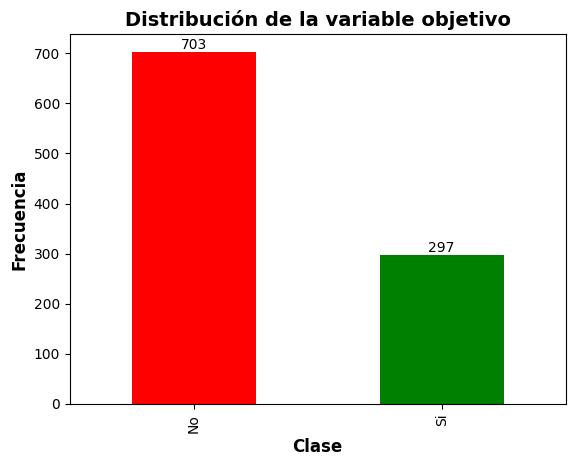

In [15]:
# Grafica la distribución de la variable objetivo
pd.Series(y).value_counts().plot(kind="bar", color=["red", "green"])
plt.title("Distribución de la variable objetivo", fontweight="bold", fontsize=14)
plt.xlabel("Clase", fontweight="bold", fontsize=12)
plt.ylabel("Frecuencia", fontweight="bold", fontsize=12)
# Agrega los nombres de las clases en el eje (0 = No, 1 = Si)
plt.xticks([0, 1], ["No", "Si"])
# Agrega las etiquetas a cada clase
for i, count in enumerate(pd.Series(y).value_counts()):
    plt.text(i, count, str(count), ha='center', va='bottom')
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29,
                                                    stratify = y)

In [6]:
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]  # probabilidades clase positiva

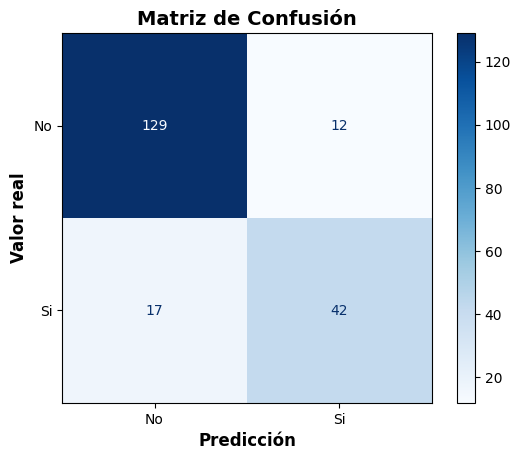

In [7]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Si"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión", fontweight="bold", fontsize=14)
plt.xlabel("Predicción", fontweight="bold", fontsize=12)
plt.ylabel("Valor real", fontweight="bold", fontsize=12)
plt.show()


=== MÉTRICAS ===
Accuracy             : 0.8550
Precision            : 0.7778
Recall               : 0.7119
F1-score            : 0.7434


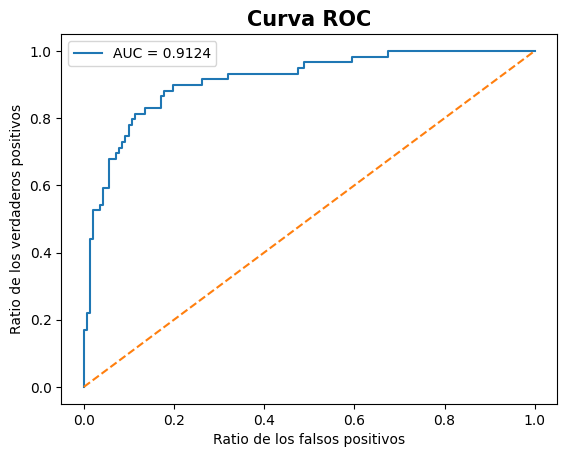

ROC-AUC: 0.9124


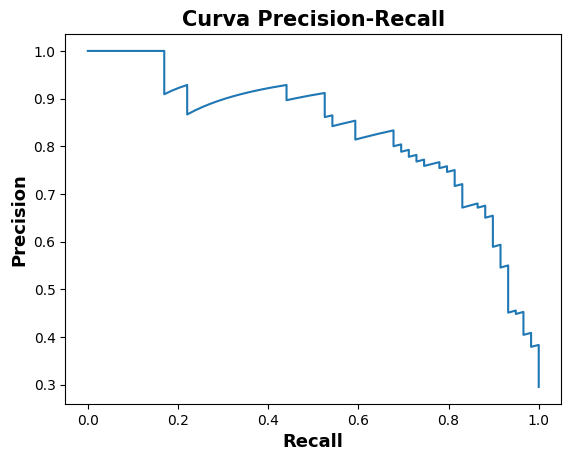

In [8]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== MÉTRICAS ===")
print(f"{'Accuracy': <20} : {accuracy:.4f}")
print(f"{'Precision':<20} : {precision:.4f}")
print(f"{'Recall':<20} : {recall:.4f}")
print(f"{'F1-score':<20}: {f1:.4f}")

# Curva ROC-AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # línea aleatoria
plt.xlabel("Ratio de los falsos positivos")
plt.ylabel("Ratio de los verdaderos positivos")
plt.title("Curva ROC", fontsize=15, fontweight="bold")
plt.legend()
plt.show()

print(f"ROC-AUC: {auc:.4f}")

# Curva precision-recall
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall", fontsize=13, fontweight="bold")
plt.ylabel("Precision", fontsize=13, fontweight="bold")
plt.title("Curva Precision-Recall", fontsize=15, fontweight="bold")
plt.show()

`Curva ROC` es una curva que muestra, para distintos umbrales del modelo:

+ TPR (Recall) en eje Y
+ FPR = FP / (FP + TN) en eje X


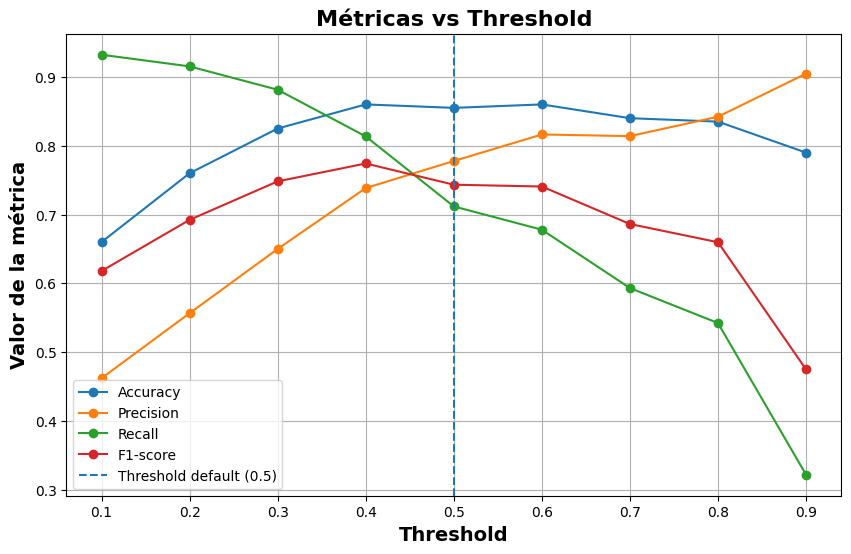

In [9]:
thresholds = np.arange(0.1, 1.0, 0.1)

accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

for threshold in thresholds:
    y_pred_custom = (y_prob >= threshold).astype(int)

    accuracy_list.append(accuracy_score(y_test, y_pred_custom))
    precision_list.append(precision_score(y_test, y_pred_custom))
    recall_list.append(recall_score(y_test, y_pred_custom))
    f1_list.append(f1_score(y_test, y_pred_custom))

plt.figure(figsize=(10,6))

plt.plot(thresholds, accuracy_list, marker='o', label='Accuracy')
plt.plot(thresholds, precision_list, marker='o', label='Precision')
plt.plot(thresholds, recall_list, marker='o', label='Recall')
plt.plot(thresholds, f1_list, marker='o', label='F1-score')
plt.axvline(x=0.5, linestyle='--', label='Threshold default (0.5)')

plt.xlabel("Threshold", fontsize=14, fontweight="bold")
plt.ylabel("Valor de la métrica", fontsize=14, fontweight="bold")
plt.title("Métricas vs Threshold", fontsize=16, fontweight="bold")

plt.legend()
plt.grid()

plt.show()

🔵 `Recall` baja cuando sube el threshold

🟢 `Precision` sube cuando sube el threshold

🟠 `F1` tiene un punto óptimo

⚫ `Accuracy` puede verse “estable” (engañoso)

Este gráfico muestra un trade-off real:

+ Es imposible maximizar todo al mismo tiempo

+ Mejorar precision suele empeorar recall

+ El threshold es una decisión de negocio, no técnica